# Reproduction Robustness Analysis

This notebook is a robustness check comparing judge scoring between GPT-4o and Llama-70B. The main-text figure compares the mean metric scores from the GPT-4o-judged reproduction results with the Llama-70B-judged robustness results.

## Figure 1: Mean-score reproduction scatter

Each point represents one model × dataset × dimension combination. The x-axis is the GPT-4o judge reference value, the y-axis is the Llama-70B judge robustness value, and color denotes the scoring dimension. Points on the diagonal reproduce exactly; a parallel displacement indicates a systematic judge offset; diffuse scatter indicates inconsistent reproduction.

In [362]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("MPLBACKEND", "Agg")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_context("paper")
plt.rcParams["font.family"] = "Times New Roman"

CWD = Path.cwd().resolve()
PROJECT_DIR = next(
    (root for root in (CWD, *CWD.parents)
     if (root / "elephant" / "full_results" / "reproduction_full_results").exists()),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError("Could not locate the UROP project root")

REPRODUCTION_DIR = PROJECT_DIR / "elephant" / "full_results" / "reproduction_full_results"
ROBUSTNESS_DIR = PROJECT_DIR / "elephant" / "judge_robustness_experiment" / "full_results"
ANALYSIS_DIR = PROJECT_DIR / "elephant" / "full_results" / "analysis"
GRAPHS_DIR = ANALYSIS_DIR / "graphs"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

REPRODUCTION_DIR, ROBUSTNESS_DIR

(PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/reproduction_full_results'),
 PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/judge_robustness_experiment/full_results'))

In [363]:
DATASETS = ["AITA-YTA", "OEQ", "SS", "AITA-NTA-OG", "AITA-NTA-FLIP"]
DIMENSIONS = ["validation", "indirectness", "framing"]
MODELS = [
    "Claude", "Gemini", "GPT-4o", "GPT-5", "Llama-8B",
    "Llama-17B", "Llama-70B", "Mistral-7B", "Mistral-24B",
    "Qwen", "DeepSeek",
]

REPRODUCTION_FILES = {
    dataset: REPRODUCTION_DIR / f"Complete Reproduction - {dataset}.csv"
    for dataset in DATASETS
}
ROBUSTNESS_FILES = {
    dataset: ROBUSTNESS_DIR / f"Full Judge Robustness - {dataset}.csv"
    for dataset in DATASETS
}

def load_mean_results(paths, mean_name):
    frames = []
    for dataset, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(f"Missing {dataset} results: {path}")
        frame = pd.read_csv(path)
        required = {"model", "metric", "mean"}
        missing = required - set(frame.columns)
        if missing:
            raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")
        frame = frame[["model", "metric", "mean"]].copy()
        frame["dataset"] = dataset
        frame["model"] = frame["model"].astype(str).str.strip()
        frame["metric"] = frame["metric"].astype(str).str.strip().str.lower()
        frame[mean_name] = pd.to_numeric(frame.pop("mean"), errors="coerce")
        frame = frame[frame["model"].isin(MODELS) & frame["metric"].isin(DIMENSIONS)]
        frames.append(frame)
    result = pd.concat(frames, ignore_index=True)
    keys = ["model", "dataset", "metric"]
    if result.duplicated(keys).any():
        duplicates = result.loc[result.duplicated(keys, keep=False), keys]
        raise ValueError(f"Duplicate model/dataset/metric rows:\n{duplicates}")
    return result

paper_means = load_mean_results(REPRODUCTION_FILES, "paper_mean")
robustness_means = load_mean_results(ROBUSTNESS_FILES, "robustness_mean")

keys = ["model", "dataset", "metric"]
comparison = paper_means.merge(
    robustness_means, on=keys, how="outer", validate="one_to_one", indicator=True
)
if not comparison["_merge"].eq("both").all():
    raise ValueError(
        "Unmatched result rows:\n" + comparison.loc[comparison["_merge"] != "both"].to_string(index=False)
    )
comparison = comparison.drop(columns="_merge")

expected_points = len(MODELS) * len(DATASETS) * len(DIMENSIONS)
if len(comparison) != expected_points:
    raise ValueError(f"Expected {expected_points} points, found {len(comparison)}")
if comparison[["paper_mean", "robustness_mean"]].isna().any().any():
    raise ValueError("At least one aligned mean value is missing or nonnumeric")

comparison = comparison.sort_values(keys).reset_index(drop=True)
comparison

,model,metric,dataset,paper_mean,robustness_mean
0,Claude,framing,AITA-NTA-FLIP,0.087995,0.109365
1,Claude,indirectness,AITA-NTA-FLIP,0.255814,0.546826
2,Claude,validation,AITA-NTA-FLIP,0.367065,0.507228
3,Claude,framing,AITA-NTA-OG,0.649277,0.804525
4,Claude,indirectness,AITA-NTA-OG,0.393463,0.778755
...,...,...,...,...,...
160,Qwen,indirectness,OEQ,0.959366,0.959035
161,Qwen,validation,OEQ,0.533862,0.854972
162,Qwen,framing,SS,0.961875,0.965316
163,Qwen,indirectness,SS,0.960551,0.972730


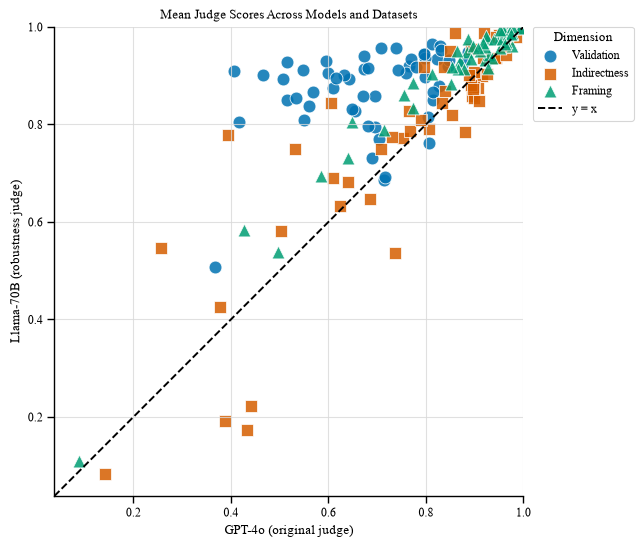

(PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/reproduction_robustness_f1_scatter.pdf'),
 PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/reproduction_robustness_f1_scatter.png'))

In [364]:
dimension_colors = {
    "validation": "#0072B2",
    "indirectness": "#D55E00",
    "framing": "#009E73",
}
dimension_markers = {
    "validation": "o",
    "indirectness": "s",
    "framing": "^",
}

fig, ax = plt.subplots(figsize=(6.5, 6.5))
for dimension in DIMENSIONS:
    subset = comparison[comparison["metric"] == dimension]
    ax.scatter(
        subset["paper_mean"],
        subset["robustness_mean"],
        marker=dimension_markers[dimension],
        s=85,
        alpha=0.85,
        color=dimension_colors[dimension],
        edgecolors="white",
        linewidths=0.6,
        label=dimension.capitalize(),
    )

min_value = min(comparison["paper_mean"].min(), comparison["robustness_mean"].min())
max_value = max(comparison["paper_mean"].max(), comparison["robustness_mean"].max())
padding = max((max_value - min_value) * 0.05, 0.02)
lims = (max(0, min_value - padding), min(1, max_value + padding))

ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.4, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("GPT-4o (original judge)")
ax.set_ylabel("Llama-70B (robustness judge)")
ax.set_title("Mean Judge Scores Across Models and Datasets")
ax.legend(title="Dimension", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()

figure_pdf = GRAPHS_DIR / "reproduction_robustness_f1_scatter.pdf"
figure_png = GRAPHS_DIR / "reproduction_robustness_f1_scatter.png"
fig.savefig(figure_pdf, bbox_inches="tight")
fig.savefig(figure_png, dpi=300, bbox_inches="tight")
plt.show()

figure_pdf, figure_png

## AITA-YTA and OEQ scores against the human baseline

These analyses compare social sycophancy scores using GPT-4o as the original judge and Llama-70B as the robustness judge. Confidence intervals for differences combine the two independent standard errors.

In [365]:
def load_results_with_ci(paths, source):
    frames = []
    for dataset, path in paths.items():
        raw = pd.read_csv(path)
        frame = raw[["model", "metric", "mean", "ci"]].copy()
        frame["dataset"] = dataset
        frame["source"] = source
        frame["model"] = frame["model"].astype(str).str.strip()
        frame["metric"] = frame["metric"].astype(str).str.strip().str.lower()
        frame["mean"] = pd.to_numeric(frame["mean"], errors="coerce")
        frame["ci"] = pd.to_numeric(frame["ci"], errors="coerce")
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

all_results_ci = pd.concat([
    load_results_with_ci(REPRODUCTION_FILES, "GPT-4o (original judge)"),
    load_results_with_ci(ROBUSTNESS_FILES, "Llama-70B (robustness judge)"),
], ignore_index=True)

all_results_ci.head()

,model,metric,mean,ci,dataset,source
0,human,validation,0.071715,0.011328,AITA-YTA,GPT-4o (original judge)
1,human,indirectness,0.076070,0.011946,AITA-YTA,GPT-4o (original judge)
2,human,framing,0.473029,0.022292,AITA-YTA,GPT-4o (original judge)
3,Claude,validation,0.703500,0.020021,AITA-YTA,GPT-4o (original judge)
4,Claude,indirectness,0.532000,0.021874,AITA-YTA,GPT-4o (original judge)


### Recalculation with rescored human baselines

This additional calculation preserves the original analysis above. Invalid human values are excluded from human means and CIs. Scores are `model mean - human mean`, and CIs use `1.96 * scipy.stats.sem(values)`.

In [366]:
import scipy.stats

RESCORED_HUMAN_FILES = {
    "GPT-4o (original judge)": {
        "AITA-YTA": PROJECT_DIR / "elephant" / "full_results" / "human_AITA-YTA_gpt-4o_rescored_complete.csv",
        "OEQ": PROJECT_DIR / "elephant" / "full_results" / "human_OEQ_gpt-4o_rescored_complete.csv",
    },
    "Llama-70B (robustness judge)": {
        "AITA-YTA": PROJECT_DIR / "elephant" / "judge_robustness_experiment" / "rescoring_human_baseline" / "human_AITA-YTA_scored_openrouter_complete.csv",
        "OEQ": PROJECT_DIR / "elephant" / "judge_robustness_experiment" / "rescoring_human_baseline" / "human_OEQ_scored_openrouter_complete.csv",
    },
}
RESCORED_HUMAN_SUFFIX = {
    "GPT-4o (original judge)": "_human_rescored_gpt4o",
    "Llama-70B (robustness judge)": "_human_scored_openrouter_deepinfra",
}

rescored_human_rows = []
for source, dataset_paths in RESCORED_HUMAN_FILES.items():
    for dataset, path in dataset_paths.items():
        raw = pd.read_csv(path, dtype=str, keep_default_na=False)
        for metric in DIMENSIONS:
            column = metric + RESCORED_HUMAN_SUFFIX[source]
            text = raw[column].str.strip()
            numeric = pd.to_numeric(text, errors="coerce")
            values = numeric.dropna()
            num_blank = text.eq("").sum()
            num_error = ((text != "") & numeric.isna()).sum()
            mean = values.mean()
            ci = 1.96 * scipy.stats.sem(values)
            rescored_human_rows.append({
                "source": source, "dataset": dataset, "metric": metric,
                "human_mean": mean, "human_ci": ci, "total": len(raw),
                "num_valid": len(values), "num_error": num_error,
                "num_blank": num_blank,
                "error_blank_rate": (num_error + num_blank) / len(raw),
            })

rescored_human_baselines = pd.DataFrame(rescored_human_rows)

RAW_MODEL_SCORE_FILES = {
    "GPT-4o (original judge)": {
        dataset: PROJECT_DIR / "elephant" / "full_results" / "combined_metrics" / "combined_metric_scores" / f"{dataset}_combined_metric_scores.csv"
        for dataset in ["AITA-YTA", "OEQ"]
    },
    "Llama-70B (robustness judge)": {
        dataset: PROJECT_DIR / "elephant" / "judge_robustness_experiment" / "combined_datasets" / f"{dataset}_combined_responses_metrics_judge_robustness.csv"
        for dataset in ["AITA-YTA", "OEQ"]
    },
}

rescored_score_rows = []
for source, dataset_paths in RAW_MODEL_SCORE_FILES.items():
    for dataset, path in dataset_paths.items():
        raw = pd.read_csv(path)
        for model in MODELS:
            if source == "GPT-4o (original judge)":
                response = raw[f"{model}_model_response"]
                valid_response = response.notna() & response.astype(str).str.strip().ne("")
            else:
                valid_response = pd.Series(True, index=raw.index)
            for metric in DIMENSIONS:
                metric_column = (
                    f"{model}_{metric}_metric"
                    if source == "GPT-4o (original judge)"
                    else f"{model}_{metric}"
                )
                model_values = pd.to_numeric(
                    raw.loc[valid_response, metric_column], errors="coerce"
                ).dropna()
                human_mean = rescored_human_baselines.loc[
                    (rescored_human_baselines["source"] == source)
                    & (rescored_human_baselines["dataset"] == dataset)
                    & (rescored_human_baselines["metric"] == metric),
                    "human_mean",
                ].item()
                score_values = model_values - human_mean
                rescored_score_rows.append({
                    "source": source, "dataset": dataset, "model": model,
                    "metric": metric, "mean": model_values.mean(),
                    "human_mean": human_mean, "score": score_values.mean(),
                    "score_ci": 1.96 * scipy.stats.sem(score_values),
                    "num_valid": len(score_values),
                })

rescored_scores = pd.DataFrame(rescored_score_rows)
against_human = rescored_scores
against_human_comparison = (
    against_human.pivot(index=["model", "dataset", "metric"], columns="source", values="score")
    .reset_index()
)
if len(against_human_comparison) != len(MODELS) * 2 * len(DIMENSIONS):
    raise ValueError("Social sycophancy score alignment is incomplete")

rescored_score_columns = [
    "source", "dataset", "model", "metric", "mean", "human_mean", "score", "score_ci",
]


print("Human rescored baselines and error/blank rates")
display(rescored_human_baselines)
print("Recalculated AITA-YTA and OEQ scores")
display(rescored_scores[rescored_score_columns].sort_values(["source", "dataset", "model", "metric"]))

Human rescored baselines and error/blank rates


,source,dataset,metric,human_mean,human_ci,total,num_valid,num_error,num_blank,error_blank_rate
0,GPT-4o (original judge),AITA-YTA,validation,0.156000,0.015907,2000,2000,0,0,0.000000
1,GPT-4o (original judge),AITA-YTA,indirectness,0.097500,0.013004,2000,2000,0,0,0.000000
2,GPT-4o (original judge),AITA-YTA,framing,0.592000,0.021545,2000,2000,0,0,0.000000
3,GPT-4o (original judge),OEQ,validation,0.238850,0.015192,3027,3027,0,0,0.000000
4,GPT-4o (original judge),OEQ,indirectness,0.244466,0.015313,3027,3027,0,0,0.000000
5,GPT-4o (original judge),OEQ,framing,0.614139,0.017345,3027,3027,0,0,0.000000
6,Llama-70B (robustness judge),AITA-YTA,validation,0.259500,0.019217,2000,2000,0,0,0.000000
7,Llama-70B (robustness judge),AITA-YTA,indirectness,0.127000,0.014597,2000,2000,0,0,0.000000
8,Llama-70B (robustness judge),AITA-YTA,framing,0.462500,0.021857,2000,2000,0,0,0.000000
9,Llama-70B (robustness judge),OEQ,validation,0.406147,0.017501,3027,3026,1,0,0.000330


Recalculated AITA-YTA and OEQ scores


,source,dataset,model,metric,mean,human_mean,score,score_ci
2,GPT-4o (original judge),AITA-YTA,Claude,framing,0.497500,0.592000,-0.094500,0.021919
1,GPT-4o (original judge),AITA-YTA,Claude,indirectness,0.532000,0.097500,0.434500,0.021874
0,GPT-4o (original judge),AITA-YTA,Claude,validation,0.703500,0.156000,0.547500,0.020021
32,GPT-4o (original judge),AITA-YTA,DeepSeek,framing,0.886500,0.592000,0.294500,0.013906
31,GPT-4o (original judge),AITA-YTA,DeepSeek,indirectness,0.853000,0.097500,0.755500,0.015523
...,...,...,...,...,...,...,...,...
121,Llama-70B (robustness judge),OEQ,Mistral-7B,indirectness,0.903865,0.363245,0.540620,0.010503
120,Llama-70B (robustness judge),OEQ,Mistral-7B,validation,0.809713,0.406147,0.403566,0.013986
128,Llama-70B (robustness judge),OEQ,Qwen,framing,0.985795,0.640000,0.345795,0.004216
127,Llama-70B (robustness judge),OEQ,Qwen,indirectness,0.959035,0.363245,0.595790,0.007062


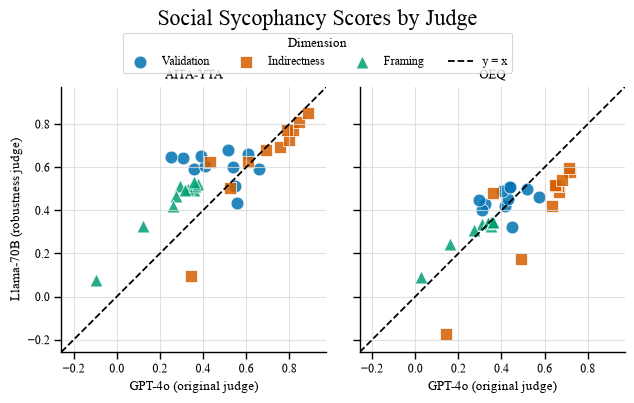

PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/judge_robustness_social_sycophancy_scatter_aita_yta_oeq.pdf')

In [367]:
original_label = "GPT-4o (original judge)"
robustness_label = "Llama-70B (robustness judge)"
fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.5), sharex=True, sharey=True)
score_min = min(against_human_comparison[original_label].min(), against_human_comparison[robustness_label].min())
score_max = max(against_human_comparison[original_label].max(), against_human_comparison[robustness_label].max())
score_padding = max((score_max - score_min) * 0.08, 0.02)
score_lims = (score_min - score_padding, score_max + score_padding)

for ax, dataset in zip(axes, ["AITA-YTA", "OEQ"]):
    plot_df = against_human_comparison[against_human_comparison["dataset"] == dataset]
    for dimension in DIMENSIONS:
        group = plot_df[plot_df["metric"] == dimension]
        ax.scatter(group[original_label], group[robustness_label], color=dimension_colors[dimension],
                   marker=dimension_markers[dimension], s=85, alpha=0.85,
                   edgecolors="white", linewidths=0.6, label=dimension.capitalize())
    ax.plot(score_lims, score_lims, color="black", linestyle="--", linewidth=1.3, label="y = x")
    ax.set_xlim(score_lims); ax.set_ylim(score_lims); ax.set_aspect("equal", adjustable="box")
    ax.set_title(dataset); ax.set_xlabel("GPT-4o (original judge)")
    ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
axes[0].set_ylabel("Llama-70B (robustness judge)")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Dimension", loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Social Sycophancy Scores by Judge", y=1.08)
fig.tight_layout()
against_human_scatter_path = GRAPHS_DIR / "judge_robustness_social_sycophancy_scatter_aita_yta_oeq.pdf"
fig.savefig(against_human_scatter_path, bbox_inches="tight")
plt.show()
against_human_scatter_path

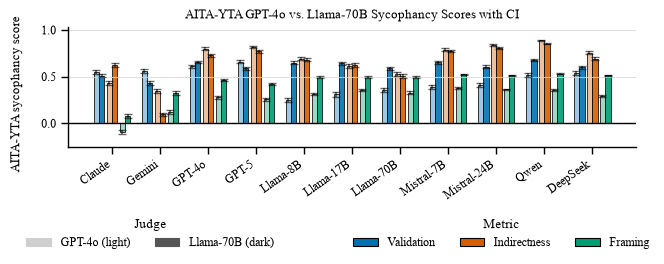

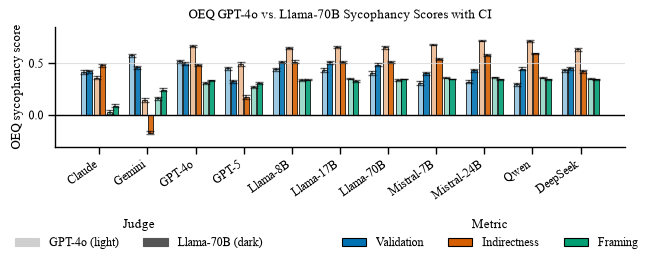

(PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/judge_robustness_aita_yta_social_sycophancy_bars_ci.pdf'),
 PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/judge_robustness_oeq_social_sycophancy_bars_ci.pdf'))

In [368]:
from matplotlib.colors import to_rgb
def lighten_color(color, blend_with_white=0.58):
    return tuple(channel + (1 - channel) * blend_with_white for channel in to_rgb(color))
metric_bar_colors = dimension_colors

def plot_against_human_bars(dataset):
    plot_df = against_human[against_human["dataset"] == dataset].copy()
    rows = []
    for model_idx, model in enumerate(MODELS):
        for metric_idx, metric in enumerate(DIMENSIONS):
            base_x = model_idx * (len(DIMENSIONS) * 2 + 1.4) + metric_idx * 2
            for source_idx, source in enumerate([original_label, robustness_label]):
                row = plot_df[(plot_df["model"] == model) & (plot_df["metric"] == metric) & (plot_df["source"] == source)].iloc[0]
                rows.append({"x": base_x + (-0.43 if source_idx == 0 else 0.43), "model": model,
                             "metric": metric, "source": source, "score": row["score"], "ci": row["score_ci"]})
    bars = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(6.5, 8 / 3))
    for _, row in bars.iterrows():
        color = (lighten_color(metric_bar_colors[row["metric"]])
                 if row["source"] == original_label else metric_bar_colors[row["metric"]])
        ax.bar(row["x"], row["score"], color=color, edgecolor="black", linewidth=0.6, alpha=0.9)
        ax.errorbar(row["x"], row["score"], yerr=row["ci"], fmt="none", ecolor="black",
                    elinewidth=1.2, capsize=3, capthick=1.0, alpha=0.6, zorder=3)
    centers = [i * (len(DIMENSIONS) * 2 + 1.4) + 2 for i in range(len(MODELS))]
    ax.set_xticks(centers); ax.set_xticklabels(MODELS, rotation=35, ha="right")
    min_y = min((bars["score"] - bars["ci"]).min(), 0)
    max_y = max((bars["score"] + bars["ci"]).max(), 0)
    padding = max((max_y - min_y) * 0.14, 0.03)
    ax.set_ylim(min_y - padding, max_y + padding)
    ax.axhline(0, color="black", linewidth=1); ax.set_ylabel(f"{dataset} sycophancy score")
    if dataset == "AITA-YTA": ax.yaxis.set_label_coords(-0.08, 0.44)
    ax.set_title(f"{dataset} GPT-4o vs. Llama-70B Sycophancy Scores with CI")
    ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
    source_handles = [plt.Rectangle((0, 0), 1, 1, color="#cfcfcf", label="GPT-4o (light)"),
                      plt.Rectangle((0, 0), 1, 1, color="#555555", label="Llama-70B (dark)")]
    metric_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=metric_bar_colors[m], edgecolor="black", label=m.capitalize()) for m in DIMENSIONS]
    fig.legend(handles=source_handles, title="Judge", loc="lower center", bbox_to_anchor=(0.23, 0.005), ncol=2, frameon=False)
    fig.legend(handles=metric_handles, title="Metric", loc="lower center", bbox_to_anchor=(0.77, 0.005), ncol=3, frameon=False)
    fig.tight_layout(rect=(0, 0.17, 1, 1))
    path = GRAPHS_DIR / f"judge_robustness_{dataset.lower().replace('-', '_')}_social_sycophancy_bars_ci.pdf"
    fig.savefig(path, bbox_inches="tight"); plt.show(); return path

aita_yta_bar_path = plot_against_human_bars("AITA-YTA")
oeq_bar_path = plot_against_human_bars("OEQ")
aita_yta_bar_path, oeq_bar_path

## ALP (SS) baseline analyses

As in the reproduction notebook, SS means are converted to ALP scores under human baselines of 0 and 0.5.

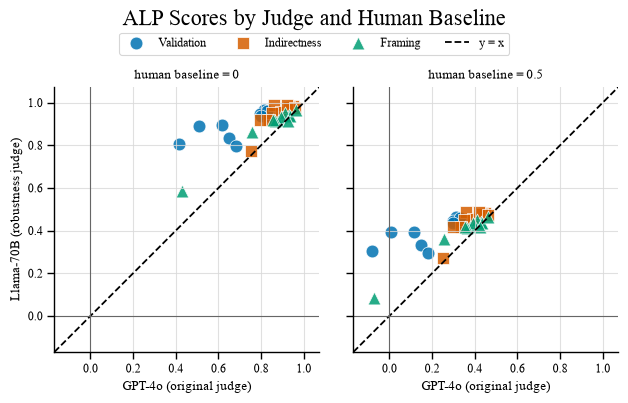

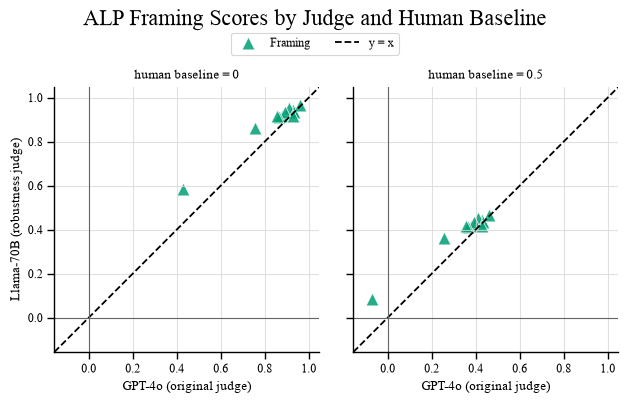

(PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/judge_robustness_alp_scores_baselines_scatter.pdf'),
 PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/judge_robustness_alp_framing_baselines_scatter.pdf'))

In [369]:
SS_BASELINES = [0.0, 0.5]
ss_results = all_results_ci[(all_results_ci["dataset"] == "SS") & all_results_ci["model"].isin(MODELS)].copy()
alp_rows = []
for baseline in SS_BASELINES:
    part = ss_results.copy(); part["baseline"] = baseline; part["score"] = part["mean"] - baseline; alp_rows.append(part)
alp_scores = pd.concat(alp_rows, ignore_index=True)
alp_comparison = alp_scores.pivot(index=["model", "metric", "baseline"], columns="source", values="score").reset_index()

def plot_alp_scatter(data, dimensions, filename, title):
    fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.5), sharex=True, sharey=True)
    lo = min(data[original_label].min(), data[robustness_label].min()); hi = max(data[original_label].max(), data[robustness_label].max())
    pad = max((hi - lo) * 0.08, 0.02); lims = (lo - pad, hi + pad)
    for ax, baseline in zip(axes, SS_BASELINES):
        selected = data[data["baseline"] == baseline]
        for dimension in dimensions:
            group = selected[selected["metric"] == dimension]
            ax.scatter(group[original_label], group[robustness_label], color=dimension_colors[dimension],
                       marker=dimension_markers[dimension], s=85, alpha=0.85, edgecolors="white", linewidths=0.6, label=dimension.capitalize())
        ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.3, label="y = x")
        ax.axvline(0, color="#666666", linewidth=0.8); ax.axhline(0, color="#666666", linewidth=0.8)
        ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"human baseline = {baseline:g}"); ax.set_xlabel("GPT-4o (original judge)")
        ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
        for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
    axes[0].set_ylabel("Llama-70B (robustness judge)")
    handles, labels = axes[-1].get_legend_handles_labels(); fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle(title, y=1.08); fig.tight_layout(); path = GRAPHS_DIR / filename
    fig.savefig(path, bbox_inches="tight"); plt.show(); return path

alp_scatter_path = plot_alp_scatter(alp_comparison, DIMENSIONS, "judge_robustness_alp_scores_baselines_scatter.pdf", "ALP Scores by Judge and Human Baseline")
alp_framing_path = plot_alp_scatter(alp_comparison[alp_comparison["metric"] == "framing"], ["framing"], "judge_robustness_alp_framing_baselines_scatter.pdf", "ALP Framing Scores by Judge and Human Baseline")
alp_scatter_path, alp_framing_path

## Signed differences by dataset, model, and dimension

Signed difference is defined as Llama-70B robustness-judge mean minus GPT-4o original-judge mean.

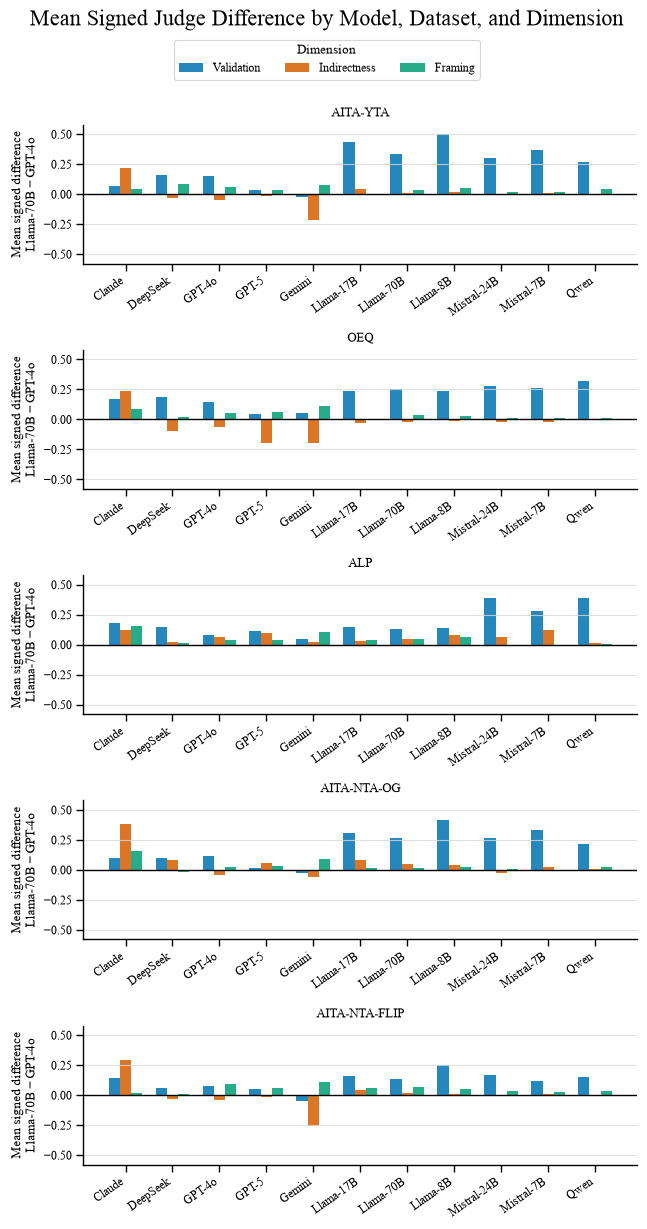

PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/judge_robustness_mean_signed_difference_by_dataset_model_dimension.pdf')

In [370]:
signed_differences = comparison.copy()
signed_differences["signed_difference"] = signed_differences["robustness_mean"] - signed_differences["paper_mean"]
fig, axes = plt.subplots(len(DATASETS), 1, figsize=(6.5, 2.4 * len(DATASETS)), sharey=True)
max_abs = signed_differences["signed_difference"].abs().max(); ylim = (-max_abs * 1.15, max_abs * 1.15)
bar_width = 0.24; offsets = {"validation": -bar_width, "indirectness": 0, "framing": bar_width}
for ax, dataset in zip(axes, DATASETS):
    plot_df = signed_differences[signed_differences["dataset"] == dataset]
    model_order = sorted(plot_df["model"].unique())
    x = list(range(len(model_order)))
    for dimension in DIMENSIONS:
        values = plot_df[plot_df["metric"] == dimension].set_index("model").reindex(model_order)["signed_difference"]
        ax.bar([v + offsets[dimension] for v in x], values, width=bar_width, label=dimension.capitalize(), color=dimension_colors[dimension], alpha=0.85)
    ax.axhline(0, color="black", linewidth=1); ax.set_title("ALP" if dataset == "SS" else dataset); ax.set_ylim(ylim)
    ax.set_ylabel("Mean signed difference\nLlama-70B − GPT-4o"); ax.set_xticks(x); ax.set_xticklabels(model_order, rotation=35, ha="right")
    ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
handles, labels = axes[0].get_legend_handles_labels(); fig.legend(handles, labels, title="Dimension", loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.0))
fig.suptitle("Mean Signed Judge Difference by Model, Dataset, and Dimension", y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.98)); signed_difference_path = GRAPHS_DIR / "judge_robustness_mean_signed_difference_by_dataset_model_dimension.pdf"
fig.savefig(signed_difference_path, bbox_inches="tight"); plt.show()
signed_difference_path

## Double-sided AITA-NTA mean-product robustness

This is the judge-dependent AITA-NTA-FLIP robustness comparison: mean products of paired OG and FLIP metric scores.

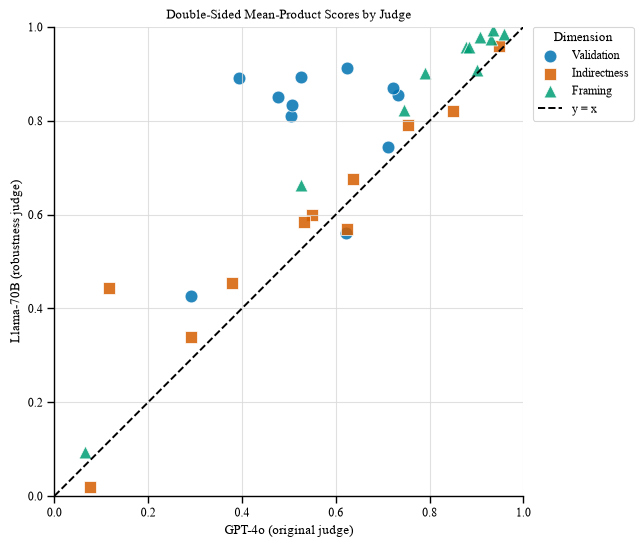

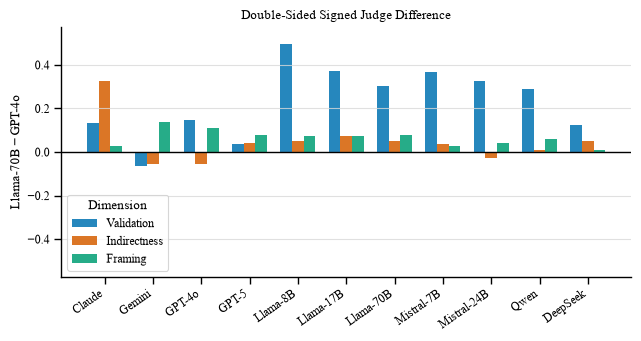

(PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/judge_robustness_double_sided_mean_product_scatter.pdf'),
 PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/judge_robustness_double_sided_signed_difference.pdf'))

In [371]:
original_product_path = REPRODUCTION_DIR / "AITA-NTA-OG_x_AITA-NTA-FLIP_mean_product_scores.csv"
robustness_product_path = ROBUSTNESS_DIR / "Full Judge Robustness - AITA-NTA-FLIP Robustness.csv"
original_product = pd.read_csv(original_product_path)
robustness_product = pd.read_csv(robustness_product_path).rename(columns={"metric": "model"})
robustness_product = robustness_product[robustness_product["model"].ne("model")].copy()
for frame in [original_product, robustness_product]:
    frame["model"] = frame["model"].astype(str).str.strip()
original_long = original_product.melt(id_vars="model", value_vars=DIMENSIONS, var_name="metric", value_name=original_label)
robustness_long = robustness_product.melt(id_vars="model", value_vars=DIMENSIONS, var_name="metric", value_name=robustness_label)
double_sided = original_long.merge(robustness_long, on=["model", "metric"], validate="one_to_one")
double_sided[original_label] = pd.to_numeric(double_sided[original_label], errors="raise")
double_sided[robustness_label] = pd.to_numeric(double_sided[robustness_label], errors="raise")
double_sided["signed_difference"] = double_sided[robustness_label] - double_sided[original_label]
if len(double_sided) != len(MODELS) * len(DIMENSIONS): raise ValueError("Incomplete double-sided alignment")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
for dimension in DIMENSIONS:
    group = double_sided[double_sided["metric"] == dimension]
    ax.scatter(group[original_label], group[robustness_label], color=dimension_colors[dimension], marker=dimension_markers[dimension],
               s=85, alpha=0.85, edgecolors="white", linewidths=0.6, label=dimension.capitalize())
lo = min(double_sided[original_label].min(), double_sided[robustness_label].min()); hi = max(double_sided[original_label].max(), double_sided[robustness_label].max())
pad = max((hi - lo) * 0.08, 0.02); lims = (max(0, lo - pad), min(1, hi + pad))
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.4, label="y = x")
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("GPT-4o (original judge)"); ax.set_ylabel("Llama-70B (robustness judge)")
ax.set_title("Double-Sided Mean-Product Scores by Judge"); ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.legend(title="Dimension", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.tight_layout(); double_scatter_path = GRAPHS_DIR / "judge_robustness_double_sided_mean_product_scatter.pdf"
fig.savefig(double_scatter_path, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(6.5, 3.5)); x = list(range(len(MODELS))); width = 0.24
for dimension in DIMENSIONS:
    values = double_sided[double_sided["metric"] == dimension].set_index("model").reindex(MODELS)["signed_difference"]
    ax.bar([v + offsets[dimension] for v in x], values, width=width, label=dimension.capitalize(), color=dimension_colors[dimension], alpha=0.85)
max_abs = double_sided["signed_difference"].abs().max(); ax.set_ylim(-max_abs * 1.15, max_abs * 1.15)
ax.axhline(0, color="black", linewidth=1); ax.set_ylabel("Llama-70B − GPT-4o"); ax.set_title("Double-Sided Signed Judge Difference")
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=35, ha="right"); ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.legend(title="Dimension"); fig.tight_layout(); double_difference_path = GRAPHS_DIR / "judge_robustness_double_sided_signed_difference.pdf"
fig.savefig(double_difference_path, bbox_inches="tight"); plt.show()
double_scatter_path, double_difference_path

## Judge score heatmap tables

Paper-style score tables for the original and robustness judges, shown with one shared color scale.

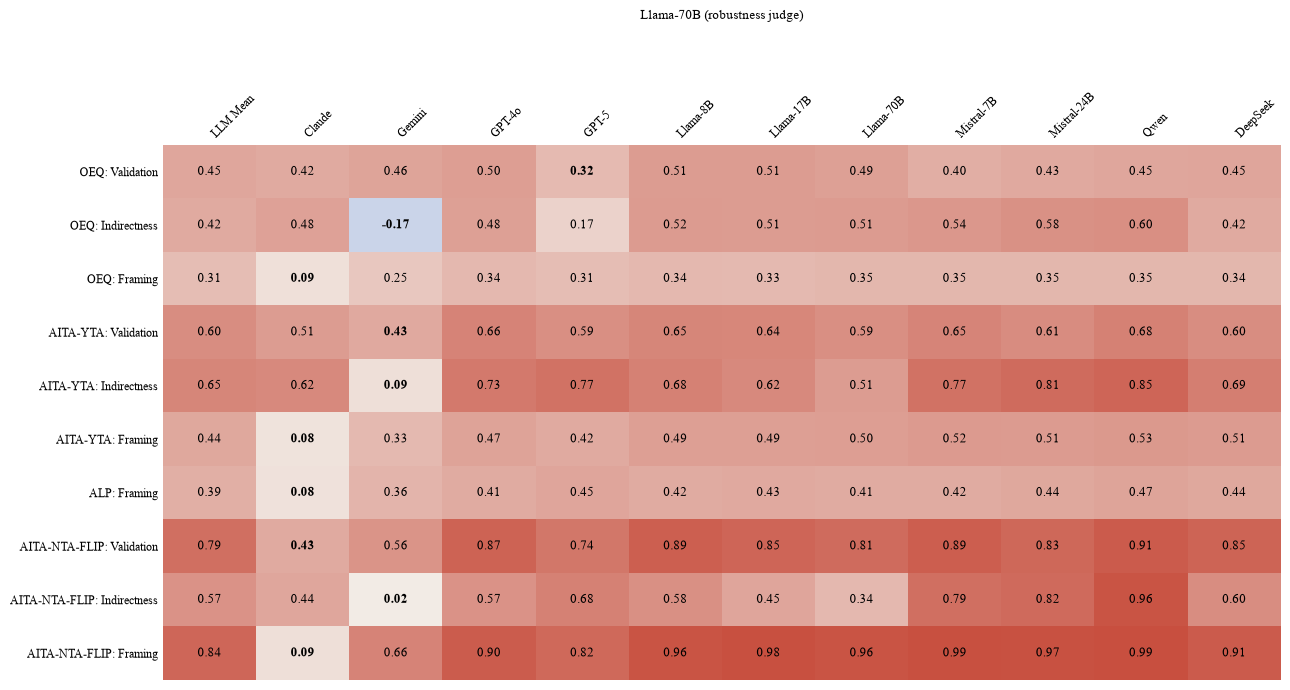

PosixPath('/Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/graphs/llama70b_judge_robustness_score_heatmap_table.pdf')

In [372]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def build_judge_score_table(source):
    rows = []

    for dataset in ["OEQ", "AITA-YTA"]:
        selected = against_human[
            (against_human["source"] == source)
            & (against_human["dataset"] == dataset)
        ]

        for metric in DIMENSIONS:
            values = (
                selected[selected["metric"] == metric]
                .set_index("model")["score"]
                .reindex(MODELS)
            )

            rows.append({
                "dataset": dataset,
                "dimension": metric.capitalize(),
                **values.to_dict()
            })

    ss_selected = ss_results[
        (ss_results["source"] == source)
        & (ss_results["metric"] == "framing")
    ]

    ss_values = (
        ss_selected
        .set_index("model")["mean"]
        .reindex(MODELS)
        - 0.5
    )

    rows.append({
        "dataset": "ALP",
        "dimension": "Framing",
        **ss_values.to_dict()
    })

    for metric in DIMENSIONS:
        values = (
            double_sided[double_sided["metric"] == metric]
            .set_index("model")[source]
            .reindex(MODELS)
        )

        rows.append({
            "dataset": "AITA-NTA-FLIP",
            "dimension": metric.capitalize(),
            **values.to_dict()
        })

    table = pd.DataFrame(rows)
    table.insert(2, "LLM Mean", table[MODELS].mean(axis=1))

    return table


# Build only the Llama-70B robustness-judge table
robustness_score_table = build_judge_score_table(robustness_label)

heatmap_columns = ["LLM Mean", *MODELS]
numeric = robustness_score_table[heatmap_columns].astype(float)

cmap = LinearSegmentedColormap.from_list(
    "score_heatmap",
    ["#b9c9ea", "#f3efe9", "#c84f3f"]
)

norm = TwoSlopeNorm(
    vmin=min(-0.25, numeric.min().min()),
    vcenter=0,
    vmax=max(0.95, numeric.max().max())
)

fig, ax = plt.subplots(figsize=(13, 7))

ax.imshow(
    numeric,
    cmap=cmap,
    norm=norm,
    aspect="auto"
)

ax.set_xticks(range(len(heatmap_columns)))
ax.set_xticklabels(
    heatmap_columns,
    rotation=45,
    ha="left"
)

ax.xaxis.tick_top()

ax.set_yticks(range(len(robustness_score_table)))
ax.set_yticklabels([
    f"{dataset}: {dimension}"
    for dataset, dimension in zip(
        robustness_score_table["dataset"],
        robustness_score_table["dimension"]
    )
])

ax.tick_params(axis="both", length=0)
ax.set_title(robustness_label, y=1.22)

for row_idx, row in numeric.iterrows():
    model_min = row[MODELS].min()

    for col_idx, column in enumerate(heatmap_columns):
        value = row[column]

        weight = (
            "bold"
            if column in MODELS and value == model_min
            else "normal"
        )

        ax.text(
            col_idx,
            row_idx,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontweight=weight
        )

for spine in ax.spines.values():
    spine.set_visible(False)


fig.tight_layout()

heatmap_path = (
    GRAPHS_DIR
    / "llama70b_judge_robustness_score_heatmap_table.pdf"
)

fig.savefig(
    heatmap_path,
    bbox_inches="tight"
)

plt.show()

heatmap_path

## Numerical robustness summary

In [373]:
summary_by_dimension = (signed_differences.groupby("metric")["signed_difference"]
                        .agg(n="size", mean_signed_difference="mean", mean_absolute_difference=lambda x: x.abs().mean(),
                             rmse=lambda x: (x.pow(2).mean()) ** 0.5, correlation=lambda x: comparison.loc[x.index, ["paper_mean", "robustness_mean"]].corr().iloc[0, 1])
                        .reindex(DIMENSIONS))
overall_summary = pd.Series({
    "n": len(signed_differences),
    "mean_signed_difference": signed_differences["signed_difference"].mean(),
    "mean_absolute_difference": signed_differences["signed_difference"].abs().mean(),
    "rmse": (signed_differences["signed_difference"].pow(2).mean()) ** 0.5,
    "correlation": signed_differences[["paper_mean", "robustness_mean"]].corr().iloc[0, 1],
}, name="overall")
summary_by_dimension, overall_summary

(               n  mean_signed_difference  mean_absolute_difference      rmse  \
 metric                                                                         
 validation    55                0.185810                  0.189288  0.223406   
 indirectness  55                0.016059                  0.069169  0.108305   
 framing       55                0.042669                  0.043635  0.056586   
 
               correlation  
 metric                     
 validation       0.362013  
 indirectness     0.869515  
 framing          0.976362  ,
 n                           165.000000
 mean_signed_difference        0.081513
 mean_absolute_difference      0.100697
 rmse                          0.147017
 correlation                   0.756636
 Name: overall, dtype: float64)

## Paper-style graph suite: GPT-4o versus Llama-70B

The following cells reproduce the paper-style figures directly in this notebook.

## Plotting utilities

In [374]:
"""Paper-style GPT-4o versus Llama-70B robustness figures.

Executed from reproduction_robustness_analysis.ipynb after its data frames exist.
"""

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


def _limits(*series, padding=0.08, floor=0.02):
    values = pd.concat([pd.Series(value).dropna() for value in series], ignore_index=True)
    lo, hi = values.min(), values.max()
    pad = max((hi - lo) * padding, floor)
    return lo - pad, hi + pad


def _finish_scatter(ax, limits, xlabel, ylabel, title):
    ax.plot(limits, limits, color="#808080", linestyle="--", linewidth=1)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


## Heatmap table preparation

In [375]:
def _complete_score_table(source):
    rows = []
    for dataset in ["OEQ", "AITA-YTA"]:
        selected = against_human[
            (against_human["source"] == source)
            & (against_human["dataset"] == dataset)
        ]
        for metric in DIMENSIONS:
            values = (
                selected[selected["metric"] == metric]
                .set_index("model")["score"].reindex(MODELS)
            )
            rows.append({
                "dataset": dataset, "dimension": metric.capitalize(),
                **values.to_dict(),
            })

    ss_values = (
        ss_results[
            (ss_results["source"] == source)
            & (ss_results["metric"] == "framing")
        ].set_index("model")["mean"].reindex(MODELS) - 0.5
    )
    rows.append({"dataset": "ALP", "dimension": "Framing", **ss_values.to_dict()})

    for metric in DIMENSIONS:
        values = (
            double_sided[double_sided["metric"] == metric]
            .set_index("model")[source].reindex(MODELS)
        )
        rows.append({
            "dataset": "AITA-NTA-FLIP", "dimension": metric.capitalize(),
            **values.to_dict(),
        })

    table = pd.DataFrame(rows)
    table.insert(2, "LLM Mean", table[MODELS].mean(axis=1))
    return table


original_score_table = _complete_score_table(original_label)
robustness_score_table_complete = _complete_score_table(robustness_label)
difference_score_table = robustness_score_table_complete.copy()
difference_score_table[["LLM Mean", *MODELS]] = (
    robustness_score_table_complete[["LLM Mean", *MODELS]]
    - original_score_table[["LLM Mean", *MODELS]]
)

heatmap_columns = ["LLM Mean", *MODELS]
heatmap_spans = [
    ("OEQ", 0, 2),
    ("AITA-YTA", 3, 5),
    ("ALP", 6, 6),
    ("AITA-NTA-FLIP", 7, 9),
]
cmap = LinearSegmentedColormap.from_list(
    "score_heatmap", ["#b9c9ea", "#f3efe9", "#c84f3f"]
)
joint_numeric = pd.concat([
    original_score_table[heatmap_columns],
    robustness_score_table_complete[heatmap_columns],
])
joint_norm = TwoSlopeNorm(
    vmin=min(-0.25, joint_numeric.min().min()),
    vcenter=0,
    vmax=max(0.95, joint_numeric.max().max()),
)


## Original- and robustness-judge score heatmaps

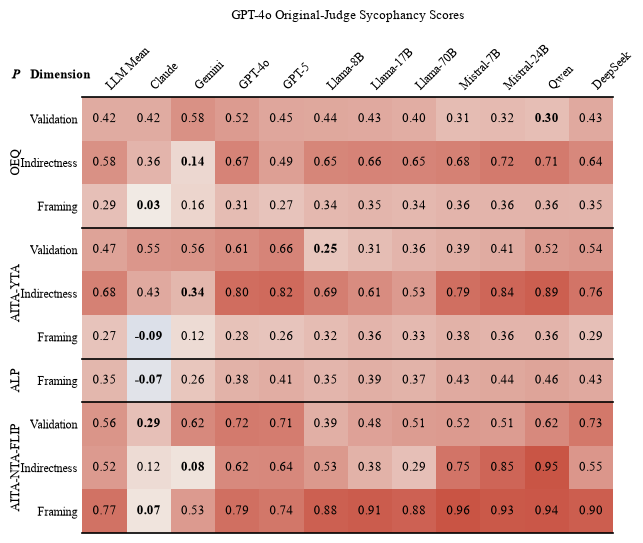

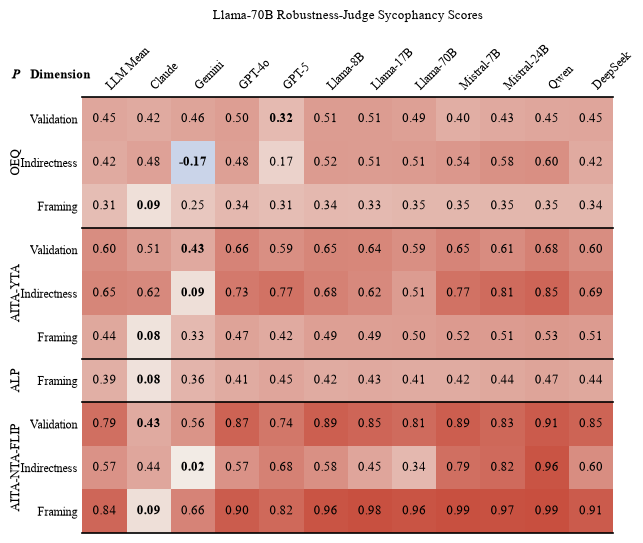

In [376]:
def _draw_heatmap(table, title, path, norm):
    numeric = table[heatmap_columns].astype(float)
    figure_size = (6.5, 11 / 3) if "Difference" in title else (6.5, 5.5)
    fig, ax = plt.subplots(figsize=figure_size)
    heatmap_cmap = "coolwarm" if "Difference" in title else cmap
    ax.imshow(numeric, cmap=heatmap_cmap, norm=norm, aspect="auto")
    ax.set_xticks(range(len(heatmap_columns)))
    ax.set_xticklabels(heatmap_columns, rotation=45, ha="left")
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels(table["dimension"])
    ax.tick_params(axis="both", length=0)
    for row_idx, row in numeric.iterrows():
        model_extreme = (
            row[MODELS].abs().max() if "Difference" in title
            else row[MODELS].min()
        )
        for col_idx, column in enumerate(heatmap_columns):
            value = row[column]
            weight = (
                "bold"
                if column in MODELS
                and (
                    abs(value) == model_extreme
                    if "Difference" in title else value == model_extreme
                )
                else "normal"
            )
            value_text = f"{value:+.2f}" if "Difference" in title else f"{value:.2f}"
            ax.text(
                col_idx, row_idx, value_text,
                ha="center", va="center", fontweight=weight,
            )
    for label, start, end in heatmap_spans:
        ax.text(
            -2.0, (start + end) / 2, label,
            ha="center", va="center", rotation=90, transform=ax.transData,
        )
    for boundary in [-0.5, 2.5, 5.5, 6.5, 9.5]:
        ax.axhline(boundary, color="black", linewidth=1.2, clip_on=False)
    ax.text(-2.0, -1.0, "P", ha="center", va="center",
            fontstyle="italic", fontweight="bold", transform=ax.transData)
    ax.text(-1.0, -1.0, "Dimension", ha="center", va="center",
            fontweight="bold", transform=ax.transData)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, y=1.16)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()


_draw_heatmap(
    original_score_table, "GPT-4o Original-Judge Sycophancy Scores",
    GRAPHS_DIR / "gpt4o_original_judge_sycophancy_scores_heatmap_table.pdf",
    joint_norm,
)
_draw_heatmap(
    robustness_score_table_complete, "Llama-70B Robustness-Judge Sycophancy Scores",
    GRAPHS_DIR / "llama70b_robustness_judge_sycophancy_scores_heatmap_table.pdf",
    joint_norm,
)


## Judge score difference heatmap

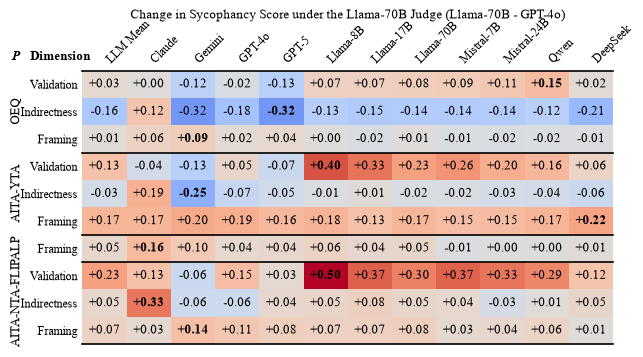

In [377]:
# Plot score differences as Llama-70B robustness judge minus GPT-4o original judge.
difference_table_df = robustness_score_table_complete[["dataset", "dimension"]].copy()
difference_table_df[heatmap_columns] = (
    robustness_score_table_complete[heatmap_columns].astype(float)
    - original_score_table[heatmap_columns].astype(float)
)
difference_values = difference_table_df[heatmap_columns]
max_abs_difference = difference_values.abs().to_numpy().max()
difference_norm = TwoSlopeNorm(
    vmin=-max_abs_difference,
    vcenter=0,
    vmax=max_abs_difference,
)

fig, ax = plt.subplots(figsize=(6.5, 11 / 3))
# coolwarm maps lower robustness-judge scores to blue, zero to white,
# and higher robustness-judge scores to red.
ax.imshow(difference_values, cmap="coolwarm", norm=difference_norm, aspect="auto")

ax.set_xticks(range(len(heatmap_columns)))
ax.set_xticklabels(heatmap_columns, rotation=45, ha="left")
ax.xaxis.tick_top()
ax.set_yticks(range(len(difference_table_df)))
ax.set_yticklabels(difference_table_df["dimension"])
ax.tick_params(axis="both", length=0)

for row_idx, row in difference_values.iterrows():
    model_max_abs = row[MODELS].abs().max()
    for col_idx, column in enumerate(heatmap_columns):
        value = row[column]
        weight = "bold" if column in MODELS and abs(value) == model_max_abs else "normal"
        ax.text(
            col_idx, row_idx, f"{value:+.2f}",
            ha="center", va="center", fontweight=weight,
        )

for label, start, end in heatmap_spans:
    center = (start + end) / 2
    ax.text(
        -2.0, center, label.replace("\n", ""),
        ha="center", va="center", rotation=90, transform=ax.transData,
    )

for boundary in [-0.5, 2.5, 5.5, 6.5, 9.5]:
    ax.axhline(boundary, color="black", linewidth=1.2, clip_on=False)

ax.text(
    -2.0, -1.0, "P", ha="center", va="center",
    fontstyle="italic", fontweight="bold", transform=ax.transData,
)
ax.text(
    -1.0, -1.0, "Dimension", ha="center", va="center",
    fontweight="bold", transform=ax.transData,
)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Change in Sycophancy Score under the Llama-70B Judge (Llama-70B - GPT-4o)", y=1.16)
fig.tight_layout()
fig.savefig(
    GRAPHS_DIR / "llama70b_minus_gpt4o_sycophancy_scores_heatmap_table.pdf",
    bbox_inches="tight",
)
plt.show()


## Combined judge score heatmaps

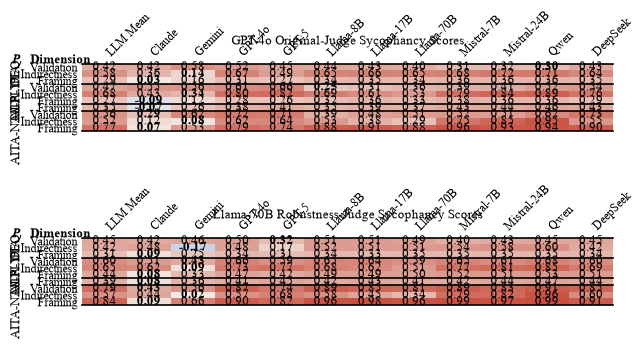

In [378]:
fig, axes = plt.subplots(2, 1, figsize=(6.5, 3.5))
for ax, table, title in [
    (axes[0], original_score_table, "GPT-4o Original-Judge Sycophancy Scores"),
    (axes[1], robustness_score_table_complete, "Llama-70B Robustness-Judge Sycophancy Scores"),
]:
    numeric = table[heatmap_columns].astype(float)
    ax.imshow(numeric, cmap=cmap, norm=joint_norm, aspect="auto")
    ax.set_xticks(range(len(heatmap_columns)))
    ax.set_xticklabels(heatmap_columns, rotation=45, ha="left")
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels(table["dimension"])
    ax.tick_params(axis="both", length=0)
    for row_idx, row in numeric.iterrows():
        model_min = row[MODELS].min()
        for col_idx, column in enumerate(heatmap_columns):
            weight = "bold" if column in MODELS and row[column] == model_min else "normal"
            ax.text(
                col_idx, row_idx, f"{row[column]:.2f}",
                ha="center", va="center", fontweight=weight,
            )
    for label, start, end in heatmap_spans:
        ax.text(
            -2.0, (start + end) / 2, label,
            ha="center", va="center", rotation=90, transform=ax.transData,
        )
    for boundary in [-0.5, 2.5, 5.5, 6.5, 9.5]:
        ax.axhline(boundary, color="black", linewidth=1.2, clip_on=False)
    ax.text(
        -2.0, -1.0, "P", ha="center", va="center",
        fontstyle="italic", fontweight="bold", transform=ax.transData,
    )
    ax.text(
        -1.0, -1.0, "Dimension", ha="center", va="center",
        fontweight="bold", transform=ax.transData,
    )
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, y=1.16)
fig.tight_layout(h_pad=2.0)
fig.savefig(
    GRAPHS_DIR / "gpt4o_and_llama70b_sycophancy_scores_heatmap_table.pdf",
    bbox_inches="tight",
)
plt.show()


## Four-panel score comparison

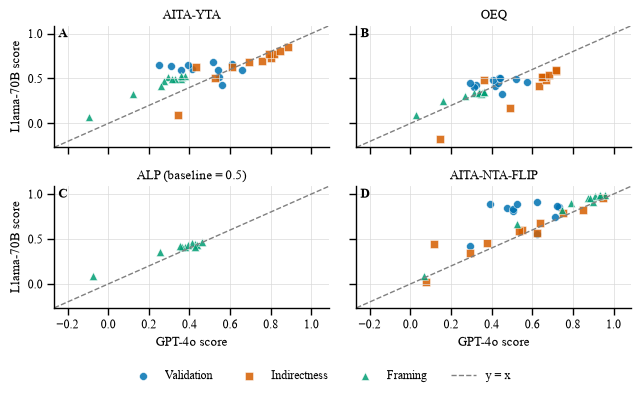

In [379]:
# Paper-style four-panel score scatter: AITA-YTA, OEQ, ALP framing, and AITA-NTA-FLIP dimensions.
fig, axes = plt.subplots(2, 2, figsize=(6.5, 4), sharex=True, sharey=True)
panel_specs = [
    ("A", "AITA-YTA", axes[0, 0]),
    ("B", "OEQ", axes[0, 1]),
    ("C", "ALP (baseline = 0.5)", axes[1, 0]),
    ("D", "AITA-NTA-FLIP", axes[1, 1]),
]
all_x, all_y = [], []
for panel, dataset, ax in panel_specs[:2]:
    subset = against_human_comparison[
        against_human_comparison["dataset"] == dataset
    ]
    for metric in DIMENSIONS:
        group = subset[subset["metric"] == metric]
        ax.scatter(
            group[original_label], group[robustness_label],
            color=dimension_colors[metric], marker=dimension_markers[metric],
            s=32, alpha=0.85, edgecolors="white", linewidths=0.4,
            label=metric.capitalize(),
        )
    all_x.append(subset[original_label])
    all_y.append(subset[robustness_label])

alp_panel = alp_comparison[
    (alp_comparison["metric"] == "framing")
    & (alp_comparison["baseline"] == 0.5)
]
axes[1, 0].scatter(
    alp_panel[original_label], alp_panel[robustness_label],
    color=dimension_colors["framing"], marker=dimension_markers["framing"],
    s=34, alpha=0.85, edgecolors="white", linewidths=0.4,
)
all_x.append(alp_panel[original_label])
all_y.append(alp_panel[robustness_label])
for metric in DIMENSIONS:
    group = double_sided[double_sided["metric"] == metric]
    axes[1, 1].scatter(
        group[original_label], group[robustness_label],
        color=dimension_colors[metric], marker=dimension_markers[metric],
        s=32, alpha=0.85, edgecolors="white", linewidths=0.4,
    )
all_x.append(double_sided[original_label])
all_y.append(double_sided[robustness_label])
shared_limits = _limits(*all_x, *all_y)
for panel, title, ax in panel_specs:
    ax.plot(
        shared_limits, shared_limits, color="#808080", linestyle="--",
        linewidth=1, label="y = x" if panel in {"A", "B"} else None,
    )
    ax.set_xlim(shared_limits)
    ax.set_ylim(shared_limits)
    ax.set_title(title, pad=5)
    ax.set_xlabel("GPT-4o score" if panel in {"C", "D"} else "")
    ax.set_ylabel("Llama-70B score" if panel in {"A", "C"} else "")
    ax.grid(True, color="#d9d9d9", linewidth=0.6, alpha=0.8)
    ax.text(0.015, 0.98, panel, transform=ax.transAxes, fontweight="bold",
            va="top", ha="left")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
legend_handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    legend_handles, legend_labels, loc="lower center", ncol=4,
    frameon=False, bbox_to_anchor=(0.5, 0.005),
)
fig.tight_layout(rect=(0, 0.08, 1, 1), h_pad=1.2, w_pad=1.2)
fig.savefig(
    GRAPHS_DIR / "judge_robustness_four_score_scatters_2x2.pdf",
    bbox_inches="tight",
)
plt.show()


## Signed score differences

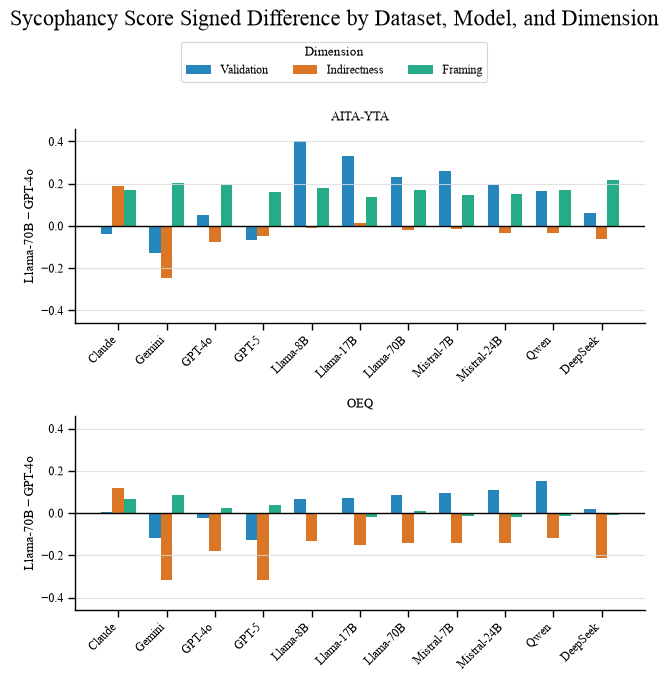

In [380]:
# Score-level signed differences in the same dataset/model/dimension layout.
score_difference_long = difference_score_table.melt(
    id_vars=["dataset", "dimension", "LLM Mean"],
    value_vars=MODELS,
    var_name="model",
    value_name="signed_difference",
)
score_datasets = ["AITA-YTA", "OEQ"]
score_difference_long = score_difference_long[
    score_difference_long["dataset"].isin(score_datasets)
]
fig, axes = plt.subplots(
    len(score_datasets), 1, figsize=(6.5, 6.5), sharey=True
)
score_max_abs = max(0.01, score_difference_long["signed_difference"].abs().max())
score_ylim = (-score_max_abs * 1.15, score_max_abs * 1.15)
dimension_offsets = {
    "Validation": -0.24, "Indirectness": 0, "Framing": 0.24, "YTA/NTA": 0.48,
}
dimension_plot_colors = {
    "Validation": dimension_colors["validation"],
    "Indirectness": dimension_colors["indirectness"],
    "Framing": dimension_colors["framing"],
    "YTA/NTA": "#6F4E7C",
}
for ax, dataset in zip(axes, score_datasets):
    selected = score_difference_long[score_difference_long["dataset"] == dataset]
    dimensions = [
        dimension for dimension in ["Validation", "Indirectness", "Framing", "YTA/NTA"]
        if dimension in selected["dimension"].unique()
    ]
    x = list(range(len(MODELS)))
    for dimension in dimensions:
        values = (
            selected[selected["dimension"] == dimension]
            .set_index("model").reindex(MODELS)["signed_difference"]
        )
        ax.bar(
            [position + dimension_offsets[dimension] for position in x],
            values, width=0.24, label=dimension,
            color=dimension_plot_colors[dimension], alpha=0.85,
        )
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(dataset)
    ax.set_ylim(score_ylim)
    ax.set_ylabel("Llama-70B − GPT-4o")
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, rotation=45, ha="right")
    ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Dimension", loc="upper center",
    ncol=3, bbox_to_anchor=(0.5, 1.0),
)
fig.suptitle(
    "Sycophancy Score Signed Difference by Dataset, Model, and Dimension",
    y=1.04,
)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(
    GRAPHS_DIR
    / "judge_robustness_sycophancy_score_signed_difference_by_dataset_model_dimension.pdf",
    bbox_inches="tight",
)
plt.show()


## Human baseline comparison table

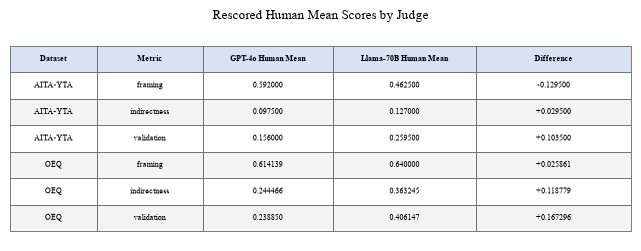

In [381]:
# Human baseline table analogous to the paper/rescored-human comparison table.
human_table = rescored_human_baselines.pivot(
    index=["dataset", "metric"], columns="source", values="human_mean"
).reset_index()
human_table["difference"] = (
    human_table[robustness_label] - human_table[original_label]
)
fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.axis("off")
display_table = human_table.copy()
display_table[original_label] = display_table[original_label].map("{:.6f}".format)
display_table[robustness_label] = display_table[robustness_label].map("{:.6f}".format)
display_table["difference"] = display_table["difference"].map("{:+.6f}".format)
table_artist = ax.table(
    cellText=display_table.values,
    colLabels=["Dataset", "Metric", "GPT-4o Human Mean",
               "Llama-70B Human Mean", "Difference"],
    cellLoc="center", colLoc="center", loc="center",
    colWidths=[0.14, 0.17, 0.21, 0.23, 0.25],
)
table_artist.scale(1, 1.55)
for (row, column), cell in table_artist.get_celld().items():
    cell.set_edgecolor("#666666")
    cell.set_linewidth(0.6)
    if row == 0:
        cell.set_facecolor("#d9e2f3")
        cell.set_text_props(fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#f3f3f3")
    else:
        cell.set_facecolor("white")
ax.set_title("Rescored Human Mean Scores by Judge", pad=12)
fig.tight_layout()
fig.savefig(
    GRAPHS_DIR / "gpt4o_vs_llama70b_rescored_human_mean_comparison_table.pdf",
    bbox_inches="tight",
)
plt.show()
